# Clase 1. Manejo de fechas, frecuencias y estructura de datos temporales

## Tópicos Selectos de Matemáticas Aplicadas II

En muchos problemas de ciencia de datos, el orden de las observaciones contiene información esencial. Esto ocurre, por ejemplo, al estudiar:

- incidencia de enfermedades a lo largo del tiempo;
- concentraciones de contaminantes atmosféricos;
- temperatura, precipitación y otras variables meteorológicas;
- demanda de energía;
- indicadores económicos o financieros.

En estos casos, las observaciones no deben considerarse simplemente como filas independientes de una tabla. El instante en el que ocurre cada observación y la separación temporal entre observaciones forman parte de la estructura matemática del problema.

Una serie temporal puede representarse como

$$
\{X_t\}_{t=1}^{T},
$$

donde $X_t$ representa el valor observado de una variable en el instante $t$.

Si en cada instante se observan varias variables, tenemos una serie temporal multivariada:

$$
\mathbf{X}_t =
\left(
X_{1,t},X_{2,t},\ldots,X_{p,t}
\right).
$$

Por ejemplo, para estudiar contaminación atmosférica podríamos tener

$$
\mathbf{X}_t =
\left(
O_{3,t},
PM_{2.5,t},
PM_{10,t},
T_t,
RH_t,
V_t
\right),
$$

donde $T_t$ representa temperatura, $RH_t$ humedad relativa y $V_t$ velocidad del viento.



## Flujo de trabajo

Durante esta clase seguiremos el esquema

$$
\boxed{
\text{datos originales}
\rightarrow
\text{fecha}
\rightarrow
\text{índice temporal}
\rightarrow
\text{frecuencia}
\rightarrow
\text{diagnóstico}
\rightarrow
\text{remuestreo}
}
$$

Un aspecto importante será distinguir entre:

- **frecuencia de observación:** cada cuánto se registraron originalmente los datos;
- **frecuencia de análisis:** cada cuánto queremos representar el fenómeno.

Por ejemplo, disponer de observaciones diarias no implica necesariamente que el análisis deba realizarse diariamente. Dependiendo del problema, puede ser conveniente construir series semanales o mensuales.

La elección de la frecuencia temporal no es únicamente una decisión computacional: modifica la información que conserva la serie y, por tanto, puede modificar las conclusiones del análisis.

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. De una columna de fechas a una estructura temporal

En un conjunto de datos, una variable temporal puede aparecer inicialmente como una columna de texto, por ejemplo:

| fecha | valor |
|---|---:|
| 2026-01-01 | 15.2 |
| 2026-01-02 | 14.8 |
| 2026-01-03 | 16.1 |

Aunque visualmente reconocemos que `fecha` representa tiempo, para `pandas` esta columna puede seguir siendo simplemente una cadena de caracteres.

Para realizar operaciones temporales es necesario convertirla a un tipo de dato de fecha mediante:

`pd.to_datetime()`.

Posteriormente podemos utilizar la fecha como índice de la tabla. Esto permite que cada observación quede asociada directamente con un instante temporal.

Si las observaciones se realizan en los tiempos

$$
t_1,t_2,\ldots,t_T,
$$

entonces una serie temporal puede representarse como el conjunto de pares

$$
\left\{
(t_1,X_{t_1}),
(t_2,X_{t_2}),
\ldots,
(t_T,X_{t_T})
\right\}.
$$

En `pandas`, esta estructura se representa naturalmente mediante un `DatetimeIndex`.


### ¿Por qué utilizar un `DatetimeIndex`?

Una vez que la fecha forma parte del índice temporal podemos realizar de manera directa operaciones como:

- seleccionar observaciones de un intervalo;
- agrupar por mes, semana o año;
- calcular diferencias entre fechas;
- identificar huecos temporales;
- construir rezagos;
- calcular ventanas móviles;
- cambiar la frecuencia de la serie.

Antes de trabajar con datos reales, construiremos un pequeño ejemplo para observar la diferencia entre:

1. almacenar fechas como texto;
2. convertirlas a objetos temporales;
3. utilizar las fechas como índice.

In [69]:
datos_ejemplo = pd.DataFrame({
    "fecha": [
        "2026-01-01",
        "2026-01-02",
        "2026-01-03",
        "2026-01-04",
        "2026-01-05",
        "2026-01-06",
        "2026-01-07"
    ],
    "temperatura": [
        15.2,
        14.8,
        16.1,
        17.3,
        16.9,
        15.7,
        14.9
    ]
})

print("Tabla original:")
display(datos_ejemplo)

print("\nTipos de datos:")
print(datos_ejemplo.dtypes)

Tabla original:


,fecha,temperatura
0,2026-01-01,15.2
1,2026-01-02,14.8
2,2026-01-03,16.1
3,2026-01-04,17.3
4,2026-01-05,16.9
5,2026-01-06,15.7
6,2026-01-07,14.9



Tipos de datos:
fecha              str
temperatura    float64
dtype: object


## 2. Conversión de la variable temporal

La función `pd.to_datetime()` permite transformar una columna que contiene fechas en texto a un tipo temporal reconocido por `pandas`.

Después de la conversión, cada elemento deja de ser una cadena de caracteres y pasa a representar un instante de tiempo.

Si una observación está asociada con una fecha $t_i$, entonces podemos pensar en ella como

$$
X(t_i).
$$

Esta transformación es fundamental porque muchas operaciones de análisis temporal dependen de que `pandas` reconozca correctamente la variable de fecha.

Una vez convertida la columna, utilizaremos `set_index()` para construir un `DatetimeIndex`.

El resultado será una estructura de la forma

$$
\begin{array}{c|c}
t & X_t \\
\hline
t_1 & X_{t_1} \\
t_2 & X_{t_2} \\
\vdots & \vdots \\
t_T & X_{t_T}
\end{array}
$$

donde el tiempo deja de ser una columna ordinaria y pasa a determinar el índice de las observaciones.

También verificaremos que las fechas estén ordenadas cronológicamente, ya que el orden temporal será esencial en todos los análisis posteriores.

In [70]:
datos_temporales = datos_ejemplo.copy()

# Convertimos la columna "fecha" a un tipo temporal
datos_temporales["fecha"] = pd.to_datetime(datos_temporales["fecha"])

print("Tipos de datos después de la conversión:")
datos_temporales.dtypes

Tipos de datos después de la conversión:


fecha          datetime64[us]
temperatura           float64
dtype: object

In [71]:
datos_temporales

,fecha,temperatura
0,2026-01-01,15.2
1,2026-01-02,14.8
2,2026-01-03,16.1
3,2026-01-04,17.3
4,2026-01-05,16.9
5,2026-01-06,15.7
6,2026-01-07,14.9


In [72]:
# Construcción del índice temporal
datos_temporales = (
    datos_temporales
    .set_index("fecha")
    .sort_index()
)


display(datos_temporales)

print("\nTipo del índice:")
print(type(datos_temporales.index))

print("\n¿El índice está ordenado cronológicamente?") # .is_monotonic_increasing: Sirve para comprobar si los datos de tu serie están ordenados de menor a mayor
print(datos_temporales.index.is_monotonic_increasing)

,temperatura
fecha,
2026-01-01,15.2
2026-01-02,14.8
2026-01-03,16.1
2026-01-04,17.3
2026-01-05,16.9
2026-01-06,15.7
2026-01-07,14.9



Tipo del índice:
<class 'pandas.DatetimeIndex'>

¿El índice está ordenado cronológicamente?
True


## 3. Frecuencia temporal de una serie

Una vez construido el índice temporal, es importante determinar con qué frecuencia fueron registradas las observaciones.

Si los tiempos de observación son

$$
t_1,t_2,\ldots,t_T,
$$

podemos definir los intervalos entre observaciones consecutivas como

$$
\Delta t_i = t_i - t_{i-1}.
$$

Cuando todos los intervalos son iguales,

$$
\Delta t_2=\Delta t_3=\cdots=\Delta t_T,
$$

decimos que la serie tiene una **frecuencia regular**.

Por ejemplo, una serie diaria regular satisface

$$
t_i-t_{i-1}=1\text{ día}
$$

para todas las observaciones consecutivas.

En cambio, si algunos intervalos tienen diferente duración, la serie es **irregular**. Esto puede ocurrir por:

- observaciones faltantes;
- fallas de sensores;
- diferencias en los calendarios de registro;
- datos recolectados únicamente cuando ocurre un evento;
- integración de distintas fuentes de información.



### ¿Por qué importa la regularidad temporal?

Muchos procedimientos posteriores suponen que las observaciones están igualmente espaciadas. Esto ocurre, por ejemplo, en:

- ventanas móviles;
- rezagos;
- descomposición de series;
- análisis de autocorrelación;
- modelos de pronóstico.

Por ello, antes de modelar una serie temporal debemos revisar explícitamente los intervalos entre fechas.

En `pandas`, la función `pd.infer_freq()` intenta identificar automáticamente la frecuencia de un índice temporal regular.

También podemos calcular directamente las diferencias entre fechas consecutivas para verificar la estructura de la serie.

In [7]:
print("Frecuencia inferida:")
print(pd.infer_freq(datos_temporales.index))

# Diferencias entre fechas consecutivas
diferencias_tiempo = datos_temporales.index.to_series().diff()

print("\nDiferencias entre observaciones consecutivas:")
display(diferencias_tiempo)

print("\nFrecuencias observadas de los intervalos temporales:")
display(diferencias_tiempo.value_counts(dropna=False))

Frecuencia inferida:
D

Diferencias entre observaciones consecutivas:


fecha
2026-01-01      NaT
2026-01-02   1 days
2026-01-03   1 days
2026-01-04   1 days
2026-01-05   1 days
2026-01-06   1 days
2026-01-07   1 days
Name: fecha, dtype: timedelta64[us]


Frecuencias observadas de los intervalos temporales:


fecha
1 days    6
NaT       1
Name: count, dtype: int64

## 4. ¿Qué ocurre cuando faltan fechas?

En datos reales es frecuente que una serie temporal no contenga todas las observaciones esperadas.

Supongamos que originalmente deberíamos observar una variable diariamente:

$$
t_1,t_2,t_3,t_4,t_5,\ldots
$$

pero una de las fechas no fue registrada:

$$
t_1,t_2,t_3,t_5,\ldots
$$

En este caso, la serie deja de ser regular aunque los datos disponibles parezcan estar correctamente ordenados.

Es importante distinguir entre dos situaciones:

### 1. Valor faltante

La fecha existe, pero el valor observado es desconocido:

$$
X_t = \mathrm{NA}.
$$

### 2. Fecha faltante

La fecha completa no aparece en el conjunto de datos.

Estas dos situaciones no son equivalentes.

Una fecha faltante puede pasar inadvertida si únicamente observamos la columna de valores, mientras que un valor faltante suele aparecer explícitamente como `NaN`.


### Construcción de un calendario esperado

Si conocemos la frecuencia esperada de una serie, podemos construir el conjunto completo de fechas mediante

$$
\mathcal{T}
=
\{t_{\min},t_{\min}+\Delta t,\ldots,t_{\max}\}.
$$

Después comparamos este calendario con las fechas realmente observadas.

En `pandas`, `pd.date_range()` permite construir el calendario esperado y `difference()` permite identificar las fechas ausentes.

A continuación eliminaremos intencionalmente una fecha del ejemplo para observar cómo cambia el diagnóstico de regularidad.

In [8]:
datos_irregulares = datos_temporales.drop(
    pd.Timestamp("2026-01-04")
)

print("Serie después de eliminar una fecha:")
display(datos_irregulares)

print("\nFrecuencia inferida:")
print(pd.infer_freq(datos_irregulares.index))

Serie después de eliminar una fecha:


,temperatura
fecha,
2026-01-01,15.2
2026-01-02,14.8
2026-01-03,16.1
2026-01-05,16.9
2026-01-06,15.7
2026-01-07,14.9



Frecuencia inferida:
None


In [9]:
calendario_esperado = pd.date_range(
    start=datos_irregulares.index.min(),
    end=datos_irregulares.index.max(),
    freq="D"
)

calendario_esperado

DatetimeIndex(['2026-01-01', '2026-01-02', '2026-01-03', '2026-01-04',
               '2026-01-05', '2026-01-06', '2026-01-07'],
              dtype='datetime64[us]', freq='D')

In [73]:
fechas_faltantes = calendario_esperado.difference(
    datos_irregulares.index
)

fechas_faltantes

DatetimeIndex(['2026-01-04'], dtype='datetime64[us]', freq='D')

In [11]:
# Revisión de los intervalos entre observaciones

intervalos = datos_irregulares.index.to_series().diff()

print("\nIntervalos entre fechas consecutivas:")
display(intervalos)


Intervalos entre fechas consecutivas:


fecha
2026-01-01      NaT
2026-01-02   1 days
2026-01-03   1 days
2026-01-05   2 days
2026-01-06   1 days
2026-01-07   1 days
Name: fecha, dtype: timedelta64[us]

## 5. Regularización de una serie temporal

Una vez identificadas las fechas faltantes, podemos reconstruir explícitamente la frecuencia esperada de la serie.

Supongamos que la serie observada está definida únicamente en

$$
\mathcal{T}_{obs}
=
\{t_1,t_2,t_3,t_5,t_6,\ldots\},
$$

mientras que el calendario completo debería ser

$$
\mathcal{T}
=
\{t_1,t_2,t_3,t_4,t_5,t_6,\ldots\}.
$$

La **regularización temporal** consiste en representar la serie sobre todo el conjunto $\mathcal{T}$, incluyendo aquellas fechas para las cuales no existe una observación.

Después de esta operación tendremos explícitamente

$$
X_{t_4}=\mathrm{NaN}.
$$

Esto es importante porque transforma un problema de **fecha ausente** en un problema de **valor faltante**, que posteriormente puede diagnosticarse y tratarse de manera controlada.



### `asfreq()` y `reindex()`

En `pandas` existen distintas formas de regularizar una serie.



In [12]:
# Regularización de la serie temporal

datos_regularizados = datos_irregulares.asfreq("D") # .asfreq() se utiliza para convertir una serie temporal a una frecuencia regular fija

print("Serie regularizada a frecuencia diaria:")
display(datos_regularizados)

print("\nFrecuencia almacenada en el índice:")
print(datos_regularizados.index.freq)

Serie regularizada a frecuencia diaria:


,temperatura
fecha,
2026-01-01,15.2
2026-01-02,14.8
2026-01-03,16.1
2026-01-04,NaN
2026-01-05,16.9
2026-01-06,15.7
2026-01-07,14.9



Frecuencia almacenada en el índice:
<Day>


El método **.any()** comprueba si al menos un elemento de una Serie, columna o DataFrame es verdadero (True). Si encuentra al menos un valor verdadero (o distinto de cero/vacío), devuelve True; si todos son falsos o la estructura está vacía, devuelve False

In [13]:
print("\nNúmero de valores faltantes por variable:")
display(datos_regularizados.isna().sum())

print("\nObservaciones que contienen valores faltantes:")
display(datos_regularizados[datos_regularizados.isna().any(axis=1)])

# Comparación del número de observaciones

print(f"Número de observaciones antes de regularizar : {len(datos_irregulares)}")
print(f"Número de observaciones después de regularizar: {len(datos_regularizados)}")


Número de valores faltantes por variable:


temperatura    1
dtype: int64


Observaciones que contienen valores faltantes:


,temperatura
fecha,
2026-01-04,NaN


Número de observaciones antes de regularizar : 6
Número de observaciones después de regularizar: 7


## 6. Cambio de frecuencia temporal mediante `resample`

Una vez que una serie tiene un índice temporal correctamente definido, podemos modificar su frecuencia de análisis.

Esta operación se conoce como **remuestreo temporal** o `resampling`.

Supongamos que tenemos observaciones diarias:

$$
X_1, X_2, \ldots, X_T,
$$

pero queremos construir una nueva serie semanal.

Si la variable representa una cantidad acumulable, como número de casos o precipitación, podemos definir

$$
Y_w
=
\sum_{t \in w} X_t,
$$

donde $w$ representa una semana.

En cambio, si la variable representa una magnitud como temperatura, puede ser más apropiado utilizar

$$
Y_w
=
\frac{1}{n_w}
\sum_{t \in w} X_t,
$$

es decir, el promedio de las observaciones disponibles durante la semana.


### La función de agregación depende del significado de la variable

No existe una única operación correcta para cambiar de frecuencia.

Por ejemplo:

| Variable | Posible agregación |
|---|---|
| Casos de dengue | suma |
| Precipitación | suma |
| Temperatura | media |
| Humedad relativa | media |
| Concentración de contaminantes | media o máximo |
| Velocidad del viento | media |
| Demanda eléctrica | media, máximo o suma, según el objetivo |

Por tanto, cambiar la frecuencia no debe entenderse simplemente como una operación computacional.

La función de agregación debe conservar el significado físico o científico de la variable.



### Ejemplo

Ampliaremos nuestro ejemplo a varias semanas de temperatura diaria y construiremos:

1. una serie de temperatura media semanal;
2. una serie de temperatura máxima semanal;
3. una serie de temperatura mínima semanal.

De esta manera observaremos que **una misma serie diaria puede generar diferentes representaciones semanales dependiendo de la pregunta que deseamos responder**.

In [74]:
# Serie sintética
rng = np.random.default_rng(42)

fechas = pd.date_range(
    start="2026-01-01",
    periods=35,
    freq="D"
)

# Serie sintética con una variación suave y ruido aleatorio
temperatura = (
    16
    + 2 * np.sin(np.arange(len(fechas)) * 2 * np.pi / 14)
    + rng.normal(0, 0.8, len(fechas))
)

datos_diarios = pd.DataFrame(
    {"temperatura": temperatura},
    index=fechas
)

datos_diarios.index.name = "fecha"

datos_diarios

,temperatura
fecha,
2026-01-01,16.243774
2026-01-02,16.035780
2026-01-03,18.164024
2026-01-04,18.702308
2026-01-05,16.389028
2026-01-06,16.521919
2026-01-07,16.970040
2026-01-08,15.747006
2026-01-09,15.118792


El método **`DataFrame.resample()`** es una función especializada de **pandas** para el remuestreo y transformación de series temporales. Opera de manera conceptualmente idéntica a un `groupby()`, pero agrupando las observaciones en **intervalos regulares de tiempo** basados en un índice temporal (`DatetimeIndex`, `TimedeltaIndex` o `PeriodIndex`).



| Categoría | Alias Moderno | Alias Legacy | Descripción | Ejemplo de Código |
| :--- | :--- | :--- | :--- | :--- |
| **Segundo** | `s` | `S` | Segundos | `df.resample('30s').mean()` |
| **Minuto** | `min` | `T` | Minutos | `df.resample('15min').sum()` |
| **Hora** | `h` | `H` | Horas | `df.resample('2h').mean()` |
| **Día** | `D` | `D` | Día natural / calendario | `df.resample('D').sum()` |
| **Día Hábil** | `B` | `B` | Días laborables (Lunes a Viernes) | `df.resample('B').mean()` |
| **Semana** | `W` o `W-SUN` | `W` | Semanal (cierre en domingo) | `df.resample('W').sum()` |
| **Semana** | `W-MON` | `W-MON` | Semanal (cierre en lunes) | `df.resample('W-MON').mean()` |
| **Mes (Fin)** | `ME` | `M` | Fin de mes (*Month End*) | `df.resample('ME').mean()` |
| **Mes (Inicio)** | `MS` | `MS` | Inicio de mes (*Month Start*) | `df.resample('MS').first()` |
| **Trimestre (Fin)** | `QE` | `Q` | Fin de trimestre (*Quarter End*) | `df.resample('QE').sum()` |
| **Trimestre (Inicio)**| `QS` | `QS` | Inicio de trimestre (*Quarter Start*) | `df.resample('QS').mean()` |
| **Año (Fin)** | `YE` | `Y` / `A` | Fin de año (*Year End*) | `df.resample('YE').sum()` |
| **Año (Inicio)** | `YS` | `YS` / `AS` | Inicio de año (*Year Start*) | `df.resample('YS').mean()` |



In [79]:
datos_diarios.resample("W").mean()

,temperatura
fecha,
2026-01-04,17.286471
2026-01-11,15.607764
2026-01-18,16.113046
2026-01-25,16.068848
2026-02-01,16.357075
2026-02-08,17.271086


In [21]:
temperatura_semanal = datos_diarios.resample("W").agg(
    temperatura_media=("temperatura", "mean"),
    temperatura_minima=("temperatura", "min"),
    temperatura_maxima=("temperatura", "max")
)

temperatura_semanal

,temperatura_media,temperatura_minima,temperatura_maxima
fecha,,,
2026-01-04,17.286471,16.035780,18.702308
2026-01-11,15.607764,13.753902,16.970040
2026-01-18,16.113046,14.489162,17.858664
2026-01-25,16.068848,13.707482,18.652616
2026-02-01,16.357075,13.768437,19.276981
2026-02-08,17.271086,16.912645,17.540062


## 7. Reducción y aumento de frecuencia: `downsampling` y `upsampling`

El cambio de frecuencia temporal puede realizarse en dos direcciones diferentes.

### Reducción de frecuencia: `downsampling`

Ocurre cuando pasamos de una frecuencia alta a una frecuencia más baja, por ejemplo:

$$
\text{horaria}
\longrightarrow
\text{diaria}
\longrightarrow
\text{semanal}
\longrightarrow
\text{mensual}.
$$

En este caso, varias observaciones originales deben resumirse mediante alguna función de agregación, como:

- suma;
- media;
- mediana;
- máximo;
- mínimo.

Por ejemplo, si $X_t$ representa precipitación diaria, una precipitación semanal puede construirse como

$$
P_w=\sum_{t\in w}X_t.
$$

En cambio, para temperatura podría interesarnos

$$
T_w=\frac{1}{n_w}\sum_{t\in w}X_t.
$$



### Aumento de frecuencia: `upsampling`

Ocurre cuando pasamos de una frecuencia baja a una frecuencia más alta, por ejemplo:

$$
\text{mensual}
\longrightarrow
\text{semanal}
\longrightarrow
\text{diaria}.
$$

Aquí aparece un problema diferente: la nueva frecuencia contiene instantes para los cuales **no existe una observación original**.

Por ejemplo, si conocemos únicamente una temperatura semanal,

$$
T_1,\;T_2,\;T_3,\ldots,
$$

no conocemos automáticamente los valores diarios dentro de cada semana.

Al aumentar la frecuencia, `pandas` crea esos nuevos instantes y inicialmente coloca valores faltantes:

$$
X_t=\mathrm{NaN}.
$$



### Interpolación

Una posible estrategia consiste en estimar los valores intermedios mediante interpolación.

Si conocemos dos observaciones

$$
(t_0,X_0)
\qquad\text{y}\qquad
(t_1,X_1),
$$

la interpolación lineal estima un valor intermedio mediante

$$
\widehat{X}(t)
=
X_0+
\frac{t-t_0}{t_1-t_0}
\left(X_1-X_0\right).
$$



In [29]:
# 1. Downsampling: de datos diarios a temperatura media semanal

serie_semanal = (
    datos_diarios["temperatura"]
    .resample("W")
    .mean()
)

print("Serie semanal:")
display(serie_semanal)


# 2. Upsampling:de frecuencia semanal nuevamente a frecuencia diaria

serie_diaria_incompleta = serie_semanal.resample("D").asfreq() # .asfreq(): Ejecuta el cambio de frecuencia sin aplicar ninguna función de agregación ni método de interpolación. Asigna el valor original al día correspondiente de cada semana y rellena los 6 días intermedios con NaN.

print("\nSerie después de aumentar la frecuencia:")
display(serie_diaria_incompleta.head(15))

print("\nNúmero de valores faltantes después del upsampling:",
    serie_diaria_incompleta.isna().sum())

Serie semanal:


fecha
2026-01-04    17.286471
2026-01-11    15.607764
2026-01-18    16.113046
2026-01-25    16.068848
2026-02-01    16.357075
2026-02-08    17.271086
Freq: W-SUN, Name: temperatura, dtype: float64


Serie después de aumentar la frecuencia:


fecha
2026-01-04    17.286471
2026-01-05          NaN
2026-01-06          NaN
2026-01-07          NaN
2026-01-08          NaN
2026-01-09          NaN
2026-01-10          NaN
2026-01-11    15.607764
2026-01-12          NaN
2026-01-13          NaN
2026-01-14          NaN
2026-01-15          NaN
2026-01-16          NaN
2026-01-17          NaN
2026-01-18    16.113046
Freq: D, Name: temperatura, dtype: float64


Número de valores faltantes después del upsampling: 30


In [32]:
# 3. Interpolación temporal

serie_diaria_interpolada = (
    serie_diaria_incompleta
    .interpolate(method="time")
)

comparacion = pd.DataFrame({
    "valor_semanal_expandido": serie_diaria_incompleta,
    "valor_interpolado": serie_diaria_interpolada
})


comparacion.head(15)

,valor_semanal_expandido,valor_interpolado
fecha,,
2026-01-04,17.286471,17.286471
2026-01-05,NaN,17.046656
2026-01-06,NaN,16.806841
2026-01-07,NaN,16.567025
2026-01-08,NaN,16.327210
2026-01-09,NaN,16.087395
2026-01-10,NaN,15.847579
2026-01-11,15.607764,15.607764
2026-01-12,NaN,15.679947


## 8. Selección de intervalos temporales

Una ventaja importante de utilizar un `DatetimeIndex` es que podemos seleccionar observaciones utilizando directamente fechas y periodos de tiempo.

En una serie temporal

$$
\{X_t\}_{t=1}^{T},
$$

frecuentemente no necesitamos analizar todo el intervalo disponible. Podemos estar interesados únicamente en un subconjunto temporal

$$
t_a \leq t \leq t_b.
$$

Por ejemplo:

- un año específico;
- un mes;
- una temporada;
- un intervalo alrededor de un evento extremo;
- un periodo previo y posterior a una intervención;
- determinadas horas del día.

En `pandas`, la selección temporal puede realizarse mediante `.loc[]`.



In [82]:
# Selección de intervalos temporales

print("Serie completa:")
display(datos_diarios.head())

# Selección de un intervalo específico
intervalo = datos_diarios.loc["2026-01-10":"2026-01-20"]

print("\nObservaciones entre el 10 y el 20 de enero:")
display(intervalo)

# Selección de todo un mes
enero = datos_diarios.loc["2026-01"]

print("\nNúmero de observaciones durante enero:")
print(len(enero))


Serie completa:


,temperatura
fecha,
2026-01-01,16.243774
2026-01-02,16.035780
2026-01-03,18.164024
2026-01-04,18.702308
2026-01-05,16.389028



Observaciones entre el 10 y el 20 de enero:


,temperatura
fecha,
2026-01-10,13.753902
2026-01-11,14.753663
2026-01-12,14.672378
2026-01-13,14.489162
2026-01-14,16.034025
2026-01-15,16.374007
2026-01-16,16.180334
2026-01-17,17.858664
2026-01-18,17.182750



Número de observaciones durante enero:
31


In [34]:
# Extracción de componentes temporales

datos_calendario = datos_diarios.copy()

datos_calendario["anio"] = datos_calendario.index.year
datos_calendario["mes"] = datos_calendario.index.month
datos_calendario["dia"] = datos_calendario.index.day
datos_calendario["dia_semana"] = datos_calendario.index.dayofweek
datos_calendario["nombre_dia"] = datos_calendario.index.day_name()
datos_calendario["semana_anio"] = (
    datos_calendario.index.isocalendar().week.astype(int)
)

print("\nSerie con variables de calendario:")
display(datos_calendario.head(10))


Serie con variables de calendario:


,temperatura,anio,mes,dia,dia_semana,nombre_dia,semana_anio
fecha,,,,,,,
2026-01-01,16.243774,2026,1,1,3,Thursday,1
2026-01-02,16.035780,2026,1,2,4,Friday,1
2026-01-03,18.164024,2026,1,3,5,Saturday,1
2026-01-04,18.702308,2026,1,4,6,Sunday,1
2026-01-05,16.389028,2026,1,5,0,Monday,2
2026-01-06,16.521919,2026,1,6,1,Tuesday,2
2026-01-07,16.970040,2026,1,7,2,Wednesday,2
2026-01-08,15.747006,2026,1,8,3,Thursday,2
2026-01-09,15.118792,2026,1,9,4,Friday,2


## 9. La definición de los intervalos importa: semanas, meses y etiquetas temporales

Cuando utilizamos `resample`, no basta con indicar que queremos transformar una serie a frecuencia semanal o mensual. También debemos especificar **cómo se definen los intervalos temporales**.

Este detalle es especialmente importante cuando se trabaja con datos epidemiológicos, meteorológicos o ambientales.


### ¿Qué significa realmente una semana?

Una semana puede definirse de distintas maneras.

Por ejemplo, podemos considerar intervalos que terminan:

- en domingo: `W-SUN`;
- en lunes: `W-MON`;
- en viernes: `W-FRI`.

Si una variable diaria es $X_t$, una agregación semanal puede escribirse como

$$
Y_w = \sum_{t\in I_w} X_t,
$$

donde $I_w$ representa el conjunto de días asignados a la semana $w$.

Si modificamos la definición de $I_w$, también puede cambiar $Y_w$.


### Etiqueta del intervalo

Supongamos un intervalo temporal

$$
I_k=(t_{k-1},t_k].
$$

Podemos etiquetar el resultado utilizando:

* el extremo izquierdo;
* el extremo derecho.


### ¿Qué observaciones pertenecen al intervalo?

El argumento `closed` determina qué extremo se considera incluido.

Por ejemplo:

```python
.resample("W-SUN", closed="right")
```

representa intervalos cerrados por la derecha.

Esta distinción puede parecer menor, pero es importante cuando una observación ocurre exactamente en el límite entre dos periodos.



### Aplicaciones

La elección debe corresponder a la definición utilizada en el problema.

Por ejemplo:

* en epidemiología puede ser necesario respetar semanas epidemiológicas;
* en meteorología pueden emplearse semanas o meses calendario;
* en contaminación pueden construirse máximos diarios a partir de datos horarios;
* en energía puede ser necesario diferenciar días hábiles y fines de semana.

Por ello, antes de utilizar `resample`, debemos responder: **¿Qué periodo representa cada observación resultante y qué fechas pertenecen a ese periodo?**


In [35]:
# Temperatura media para semanas que terminan en domingo
semanal_domingo = (
    datos_diarios["temperatura"]
    .resample(
        "W-SUN",
        label="right",
        closed="right"
    )
    .mean()
)

# Temperatura media para semanas que terminan en lunes
semanal_lunes = (
    datos_diarios["temperatura"]
    .resample(
        "W-MON",
        label="right",
        closed="right"
    )
    .mean()
)

comparacion_semanas = pd.DataFrame({
    "semana_termina_domingo": semanal_domingo,
    "semana_termina_lunes": semanal_lunes
})

comparacion_semanas

,semana_termina_domingo,semana_termina_lunes
fecha,,
2026-01-04,17.286471,NaN
2026-01-05,NaN,17.106983
2026-01-11,15.607764,NaN
2026-01-12,NaN,15.362528
2026-01-18,16.113046,NaN
2026-01-19,NaN,16.681651
2026-01-25,16.068848,NaN
2026-01-26,NaN,15.371108
2026-02-01,16.357075,NaN


In [36]:
# Número de observaciones incluidas en cada periodo

conteo_domingo = (
    datos_diarios["temperatura"]
    .resample("W-SUN")
    .count()
)

conteo_lunes = (
    datos_diarios["temperatura"]
    .resample("W-MON")
    .count()
)

print("\nNúmero de días incluidos en semanas que terminan en domingo:")
display(conteo_domingo)

print("\nNúmero de días incluidos en semanas que terminan en lunes:")
display(conteo_lunes)


Número de días incluidos en semanas que terminan en domingo:


fecha
2026-01-04    4
2026-01-11    7
2026-01-18    7
2026-01-25    7
2026-02-01    7
2026-02-08    3
Freq: W-SUN, Name: temperatura, dtype: int64


Número de días incluidos en semanas que terminan en lunes:


fecha
2026-01-05    5
2026-01-12    7
2026-01-19    7
2026-01-26    7
2026-02-02    7
2026-02-09    2
Freq: W-MON, Name: temperatura, dtype: int64

## 10. Efecto del cambio de frecuencia sobre la información

Cambiar la frecuencia temporal no solamente modifica el número de observaciones. También modifica la forma en que percibimos la dinámica del fenómeno.

Supongamos que observamos una serie diaria

$$
X_1,X_2,\ldots,X_T.
$$

Si construimos una serie semanal mediante promedios, obtenemos

$$
Y_w
=
\frac{1}{n_w}
\sum_{t\in I_w}X_t,
$$

donde $I_w$ representa los días que pertenecen a la semana $w$.

El promedio semanal actúa como una forma de **suavizamiento temporal**:

- reduce fluctuaciones de alta frecuencia;
- disminuye el número de observaciones;
- facilita la identificación de patrones generales;
- pero también elimina información sobre variaciones diarias.

Por tanto, existe un compromiso entre:

$$
\text{resolución temporal}
\qquad \text{y} \qquad
\text{suavizamiento}.
$$



### Ejemplo conceptual

Una serie diaria puede presentar cambios rápidos como

$$
15,\;16,\;19,\;14,\;17,\;20,\;16,
$$

mientras que el promedio semanal resume toda esa información mediante un único valor:

$$
\bar X
=
\frac{15+16+19+14+17+20+16}{7}
=
16.71.
$$

El promedio representa adecuadamente el nivel general de la semana, pero ya no permite identificar que existió un máximo de $20$.



### ¿Qué frecuencia debemos utilizar?

La respuesta depende de la pregunta del estudio.

Por ejemplo:

- para estudiar variaciones horarias de $O_3$, una serie mensual sería demasiado agregada;
- para analizar tendencias de dengue durante varios años, una frecuencia semanal puede ser más informativa que una frecuencia diaria;
- para estudiar olas de calor, los máximos diarios pueden contener más información que las medias mensuales.

Una buena práctica consiste en visualizar una misma variable a diferentes frecuencias antes de seleccionar la resolución definitiva.

A continuación compararemos la serie diaria original con sus representaciones semanal y mensual.

In [43]:
# Serie diaria original
serie_diaria = datos_diarios["temperatura"]

# Promedio semanal
serie_semanal = (
    serie_diaria
    .resample("W-SUN")
    .mean()
)
serie_semanal

fecha
2026-01-04    17.286471
2026-01-11    15.607764
2026-01-18    16.113046
2026-01-25    16.068848
2026-02-01    16.357075
2026-02-08    17.271086
Freq: W-SUN, Name: temperatura, dtype: float64

In [44]:
# Promedio mensual
serie_mensual = (
    serie_diaria
    .resample("MS")
    .mean()
)
serie_mensual

fecha
2026-01-01    16.146719
2026-02-01    17.359495
Freq: MS, Name: temperatura, dtype: float64

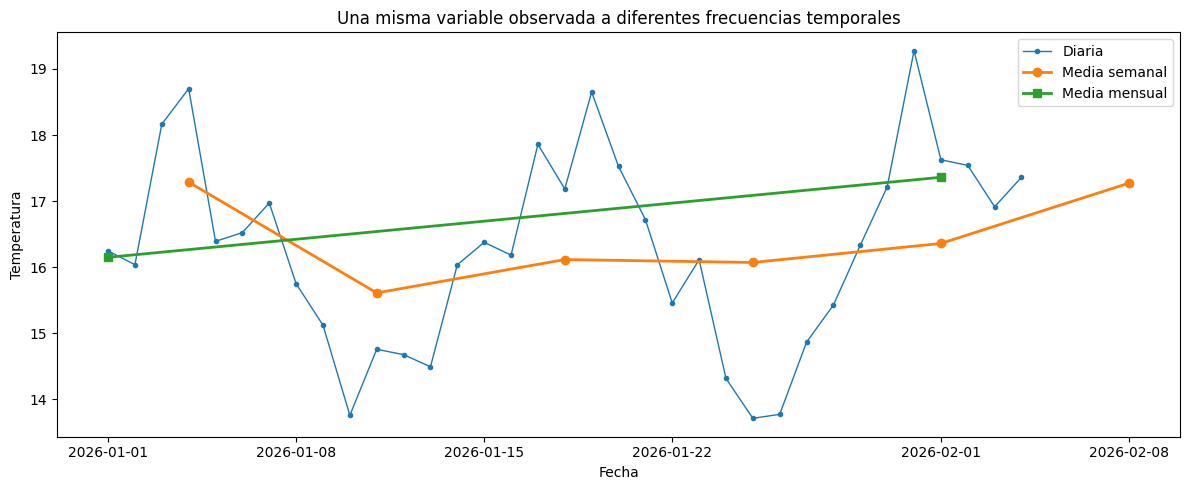

Número de observaciones:
Diarias   : 35
Semanales : 6
Mensuales : 2


In [46]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    serie_diaria.index,
    serie_diaria,
    marker="o",
    markersize=3,
    linewidth=1,
    label="Diaria"
)

ax.plot(
    serie_semanal.index,
    serie_semanal,
    marker="o",
    linewidth=2,
    label="Media semanal"
)

ax.plot(
    serie_mensual.index,
    serie_mensual,
    marker="s",
    linewidth=2,
    label="Media mensual"
)

ax.set_title("Una misma variable observada a diferentes frecuencias temporales")
ax.set_xlabel("Fecha")
ax.set_ylabel("Temperatura")
ax.legend()

plt.xticks()
plt.tight_layout()
plt.show()


print("Número de observaciones:")
print(f"Diarias   : {len(serie_diaria)}")
print(f"Semanales : {len(serie_semanal)}")
print(f"Mensuales : {len(serie_mensual)}")